Merging and cleaning the datasets


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

url = "https://raw.githubusercontent.com/Ethan004-Code/Mental_Health-Research-/main/merged_mental_health_data.csv"
df = pd.read_csv(url)

df.columns = df.columns.str.strip()
df = df[df['Year'] > 1900]
df = df.drop(columns=[
    'Population (historical estimates)_y',
    'Continent_y',
    'Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent)_y'
], errors='ignore')
df = df.drop(columns=['Entity', 'Continent_x'], errors='ignore')
df = df.dropna(thresh=5)
df = df.fillna(df.mean(numeric_only=True))

df.rename(columns={
    'Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent)_x': 'Depression_Prevalence',
    'Population (historical estimates)_x': 'Population'
}, inplace=True)

print("✅ Cleaned DataFrame shape:", df.shape)
print("✅ Columns:\n", df.columns.tolist())

df.head()


✅ Cleaned DataFrame shape: (6840, 15)
✅ Columns:
 ['Year', 'DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)', 'Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent)', 'Depression_Prevalence', 'Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Depressive disorders - Sex: Male - Age: Age-standardized (Percent)', 'Prevalence - Depressive disorders - Sex: Female - Age: Age-standardized (Percent)', 'Population', 'Prevalence - Mental disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Mental and substance use disorders - Sex: Male - Age: Age-stand

,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent),Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Depression_Prevalence,Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Male - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Female - Age: Age-standardized (Percent),Population,Prevalence - Mental disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Mental and substance use disorders - Sex: Male - Age: Age-standardized (Percent),Prevalence - Mental and substance use disorders - Sex: Female - Age: Age-standardized (Percent)
228,1990,1.696670,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036,4.291054,5.859656,12412311.0,16.659229,17.448695,17.634233
229,1991,1.734281,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250,4.293268,5.853078,13299016.0,16.765052,17.771263,17.873184
230,1992,1.791189,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501,4.298265,5.850020,14485543.0,16.874469,18.051575,18.092318
231,1993,1.776779,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958,4.303087,5.844987,15816601.0,16.990720,18.275848,18.265196
232,1994,1.712986,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779,4.306053,5.843623,17075728.0,17.112730,18.427490,18.383394


In [3]:
print(df.columns.tolist())


['Year', 'DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)', 'Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent)', 'Depression_Prevalence', 'Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Depressive disorders - Sex: Male - Age: Age-standardized (Percent)', 'Prevalence - Depressive disorders - Sex: Female - Age: Age-standardized (Percent)', 'Population', 'Prevalence - Mental disorders - Sex: Both - Age: Age-standardized (Percent)', 'Prevalence - Mental and substance use disorders - Sex: Male - Age: Age-standardized (Percent)', 'Prevalence - Mental and subst

In [4]:
target = 'Depression_Prevalence'


In [11]:
X = df.drop(columns=[target])
y = df[target]

X = X.select_dtypes(include=[np.number])
X = X.fillna(X.mean())


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "R2 Score": r2_score(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_test, y_pred)
    }


In [19]:
print("\n📊 Model Evaluation Metrics:")
for name, metrics in results.items():
    print(f"\n{name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")



📊 Model Evaluation Metrics:

Linear Regression
R2 Score: 0.9983
RMSE: 0.0379
MAE: 0.0269

Random Forest
R2 Score: 0.9995
RMSE: 0.0203
MAE: 0.0098


/tmp/ipython-input-20-1266631186.py:17: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


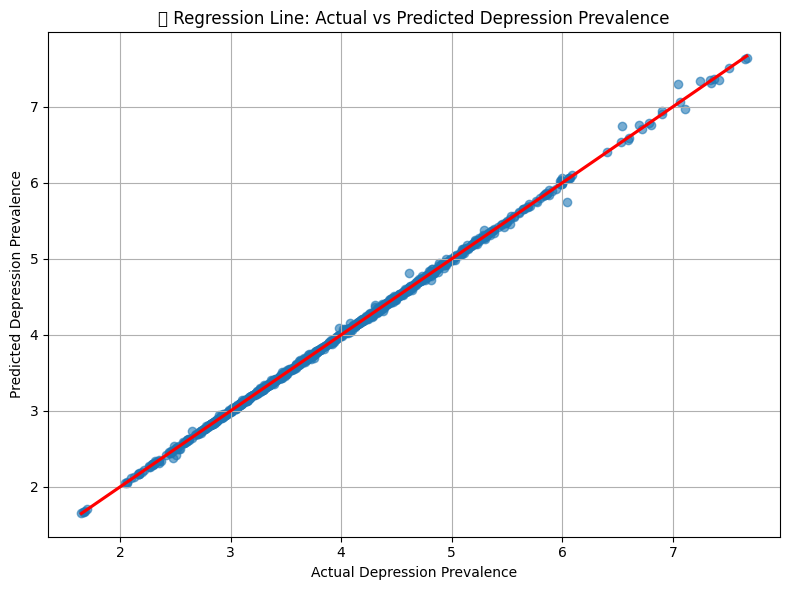

In [20]:

best_model = models["Random Forest"]
y_pred_rf = best_model.predict(X_test)

y_test = np.array(y_test)
y_pred_rf = np.array(y_pred_rf)

plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred_rf, line_kws={"color": "red"}, scatter_kws={"alpha": 0.6})

plt.xlabel("Actual Depression Prevalence")
plt.ylabel("Predicted Depression Prevalence")
plt.title("🎯 Regression Line: Actual vs Predicted Depression Prevalence")
plt.grid(True)
plt.tight_layout()
plt.show()
